In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder, StandardScaler 
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import L1, L2
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD, Adam




df = pd.read_csv(r"C:\Users\Admin\AppData\Local\Temp\Rar$DI00.107\diabetes_dataset.csv")
df

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,Male,Other,Graduate,Upper-Middle,Unemployed,Former,1,136,8.3,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,Female,White,Graduate,Middle,Employed,Never,3,76,8.8,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,Female,Black,No formal,Upper-Middle,Employed,Former,4,121,9.9,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,Female,Black,Highschool,Lower-Middle,Retired,Never,3,52,5.9,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


## Preprocessing Dataset

In [2]:
df.columns

Index(['age', 'gender', 'ethnicity', 'education_level', 'income_level',
       'employment_status', 'smoking_status', 'alcohol_consumption_per_week',
       'physical_activity_minutes_per_week', 'diet_score',
       'sleep_hours_per_day', 'screen_time_hours_per_day',
       'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp',
       'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol',
       'ldl_cholesterol', 'triglycerides', 'glucose_fasting',
       'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score',
       'diabetes_stage', 'diagnosed_diabetes'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [4]:
df.shape

(100000, 31)

In [5]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [8]:
df["gender"].unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [9]:
df[df["gender"] == "Other"].shape

(2013, 31)

In [10]:
df["gender"]= df["gender"].replace("Other",np.nan)

In [11]:
df['gender'].fillna(df['gender'].mode()[0], inplace=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_15704\3191725845.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)


## Feature Engineering

In [12]:
df["physical_activity_hours_per_week"] = df["physical_activity_minutes_per_week"] / 60

In [13]:
df.drop(["physical_activity_minutes_per_week"],axis=1, inplace=True)

In [14]:
#ldl_cholesterol ,hdl_cholesterol
df["ldl_hdl_ratio"]=df["ldl_cholesterol"] / df["hdl_cholesterol"]

In [15]:
df["triglycerides_hdl_ratio"]=df["triglycerides"] / df["hdl_cholesterol"]

In [16]:
df["blood_pressure"]=df["systolic_bp"] / df["diastolic_bp"]

In [17]:
df["relation_BMI_with_Age"]=df["bmi"] * df["age"]

In [18]:
df['lifestyle_score'] = (df['diet_score'] + df['physical_activity_hours_per_week'] - df['screen_time_hours_per_day']/10 )

In [19]:
df['family_risk_score'] = df['family_history_diabetes'] + df['hypertension_history'] + df['cardiovascular_history']

In [20]:
df['overall_risk_score'] = df['lifestyle_score'] + df['family_history_diabetes']

In [21]:
df.drop(["glucose_fasting" , "glucose_postprandial","insulin_level","hba1c"],axis=1, inplace=True)

## Visualization Dataset (EDA)

Text(0.5, 1.0, 'the diagnosed_diabetes due to age')

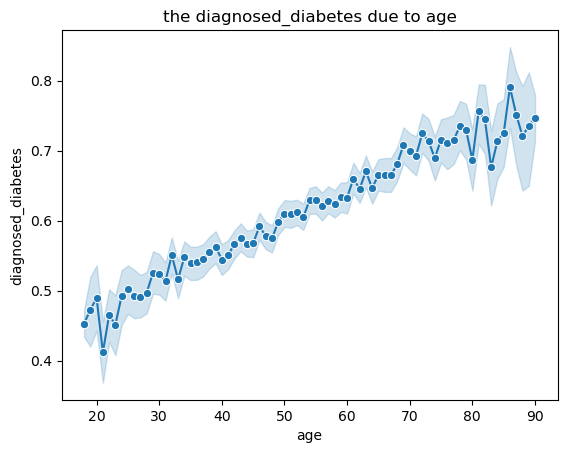

In [22]:

sns.lineplot(x= "age",y= "diagnosed_diabetes", data=df,  marker='o')
plt.title("the diagnosed_diabetes due to age")

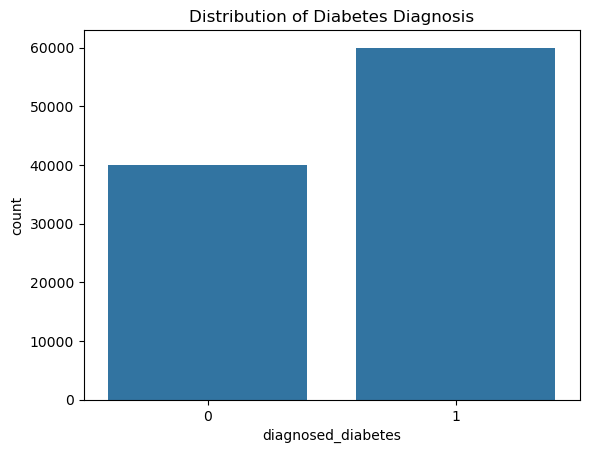

In [23]:
sns.countplot(x='diagnosed_diabetes', data=df)
plt.title('Distribution of Diabetes Diagnosis')

plt.show()

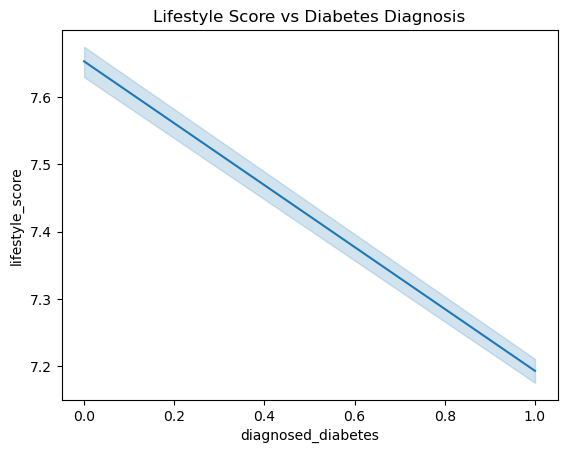

In [24]:
sns.lineplot(x='diagnosed_diabetes', y='lifestyle_score', data=df)
plt.title('Lifestyle Score vs Diabetes Diagnosis')
plt.show()

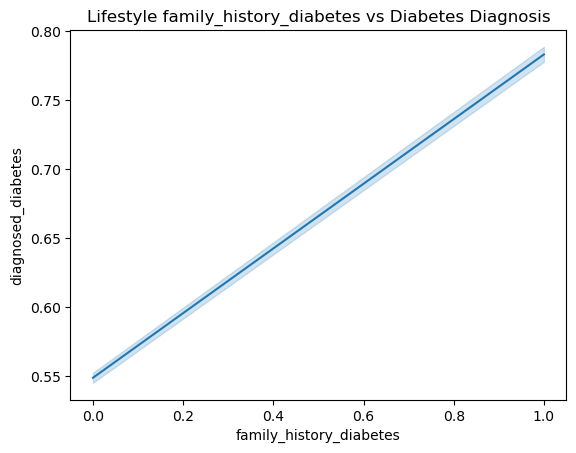

In [ ]:
sns.lineplot(x='family_history_diabetes', y='diagnosed_diabetes', data=df)
plt.title(' family_history_diabetes vs Diabetes Diagnosis')
plt.show()

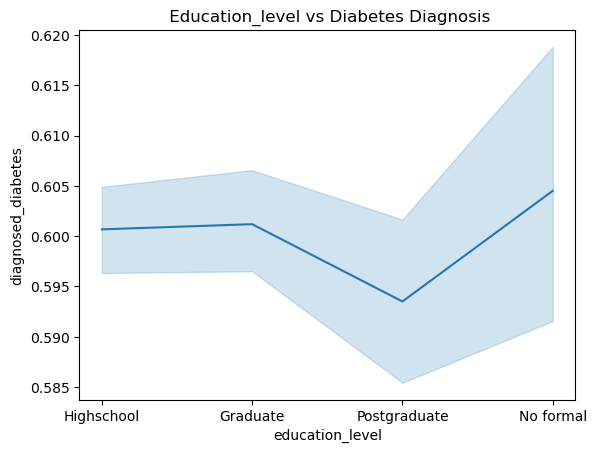

In [26]:
sns.lineplot(x='education_level', y='diagnosed_diabetes', data=df)
plt.title(' Education_level vs Diabetes Diagnosis')
plt.show()

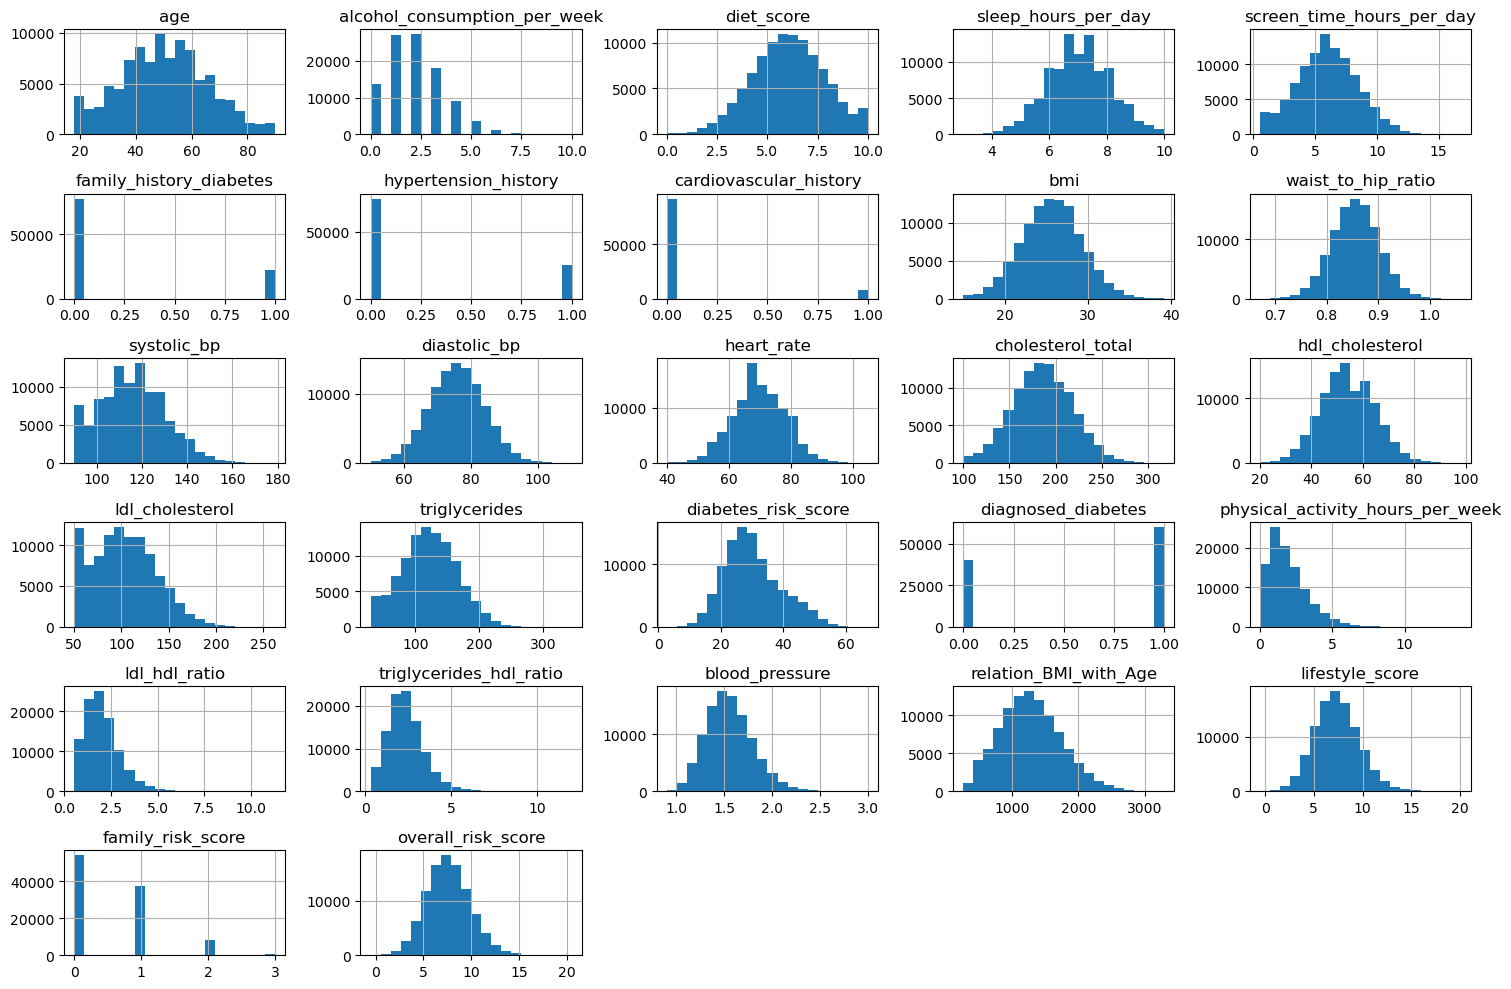

In [27]:

df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

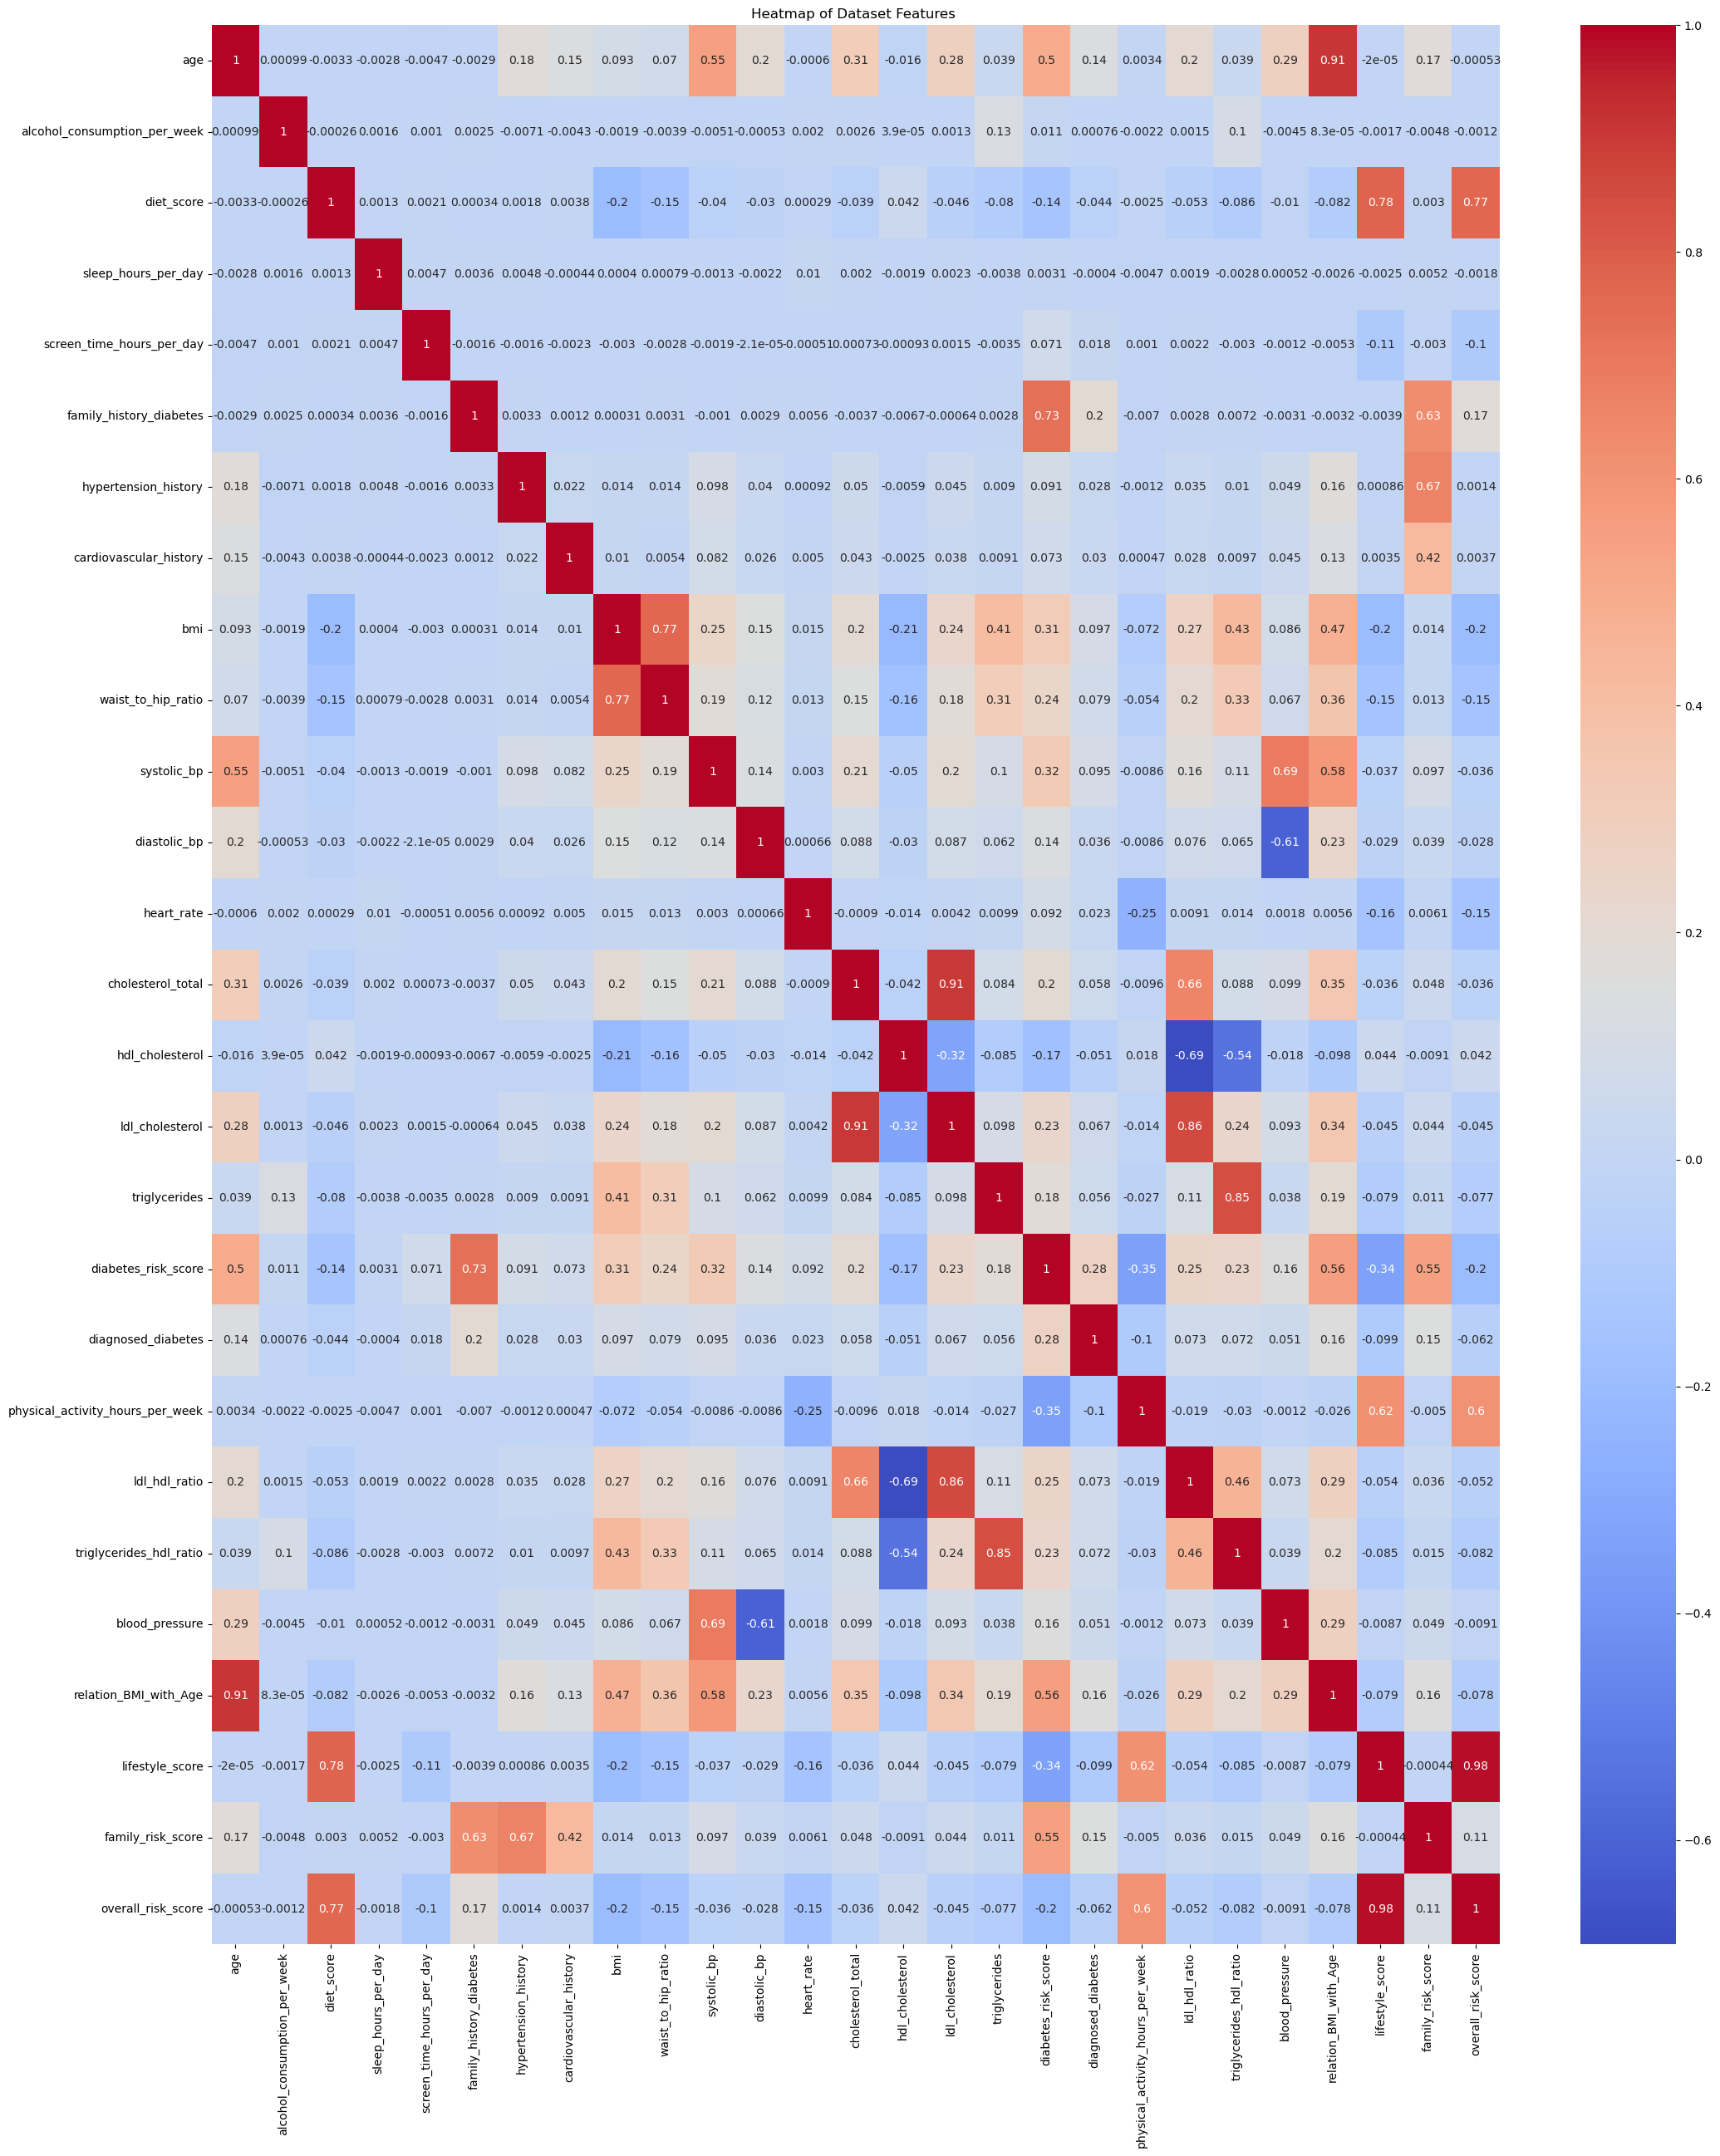

In [28]:
plt.figure(figsize=(25, 30))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Heatmap of Dataset Features ")
plt.show()

## Modeling & Evaluation

In [29]:
x= df.drop(["diagnosed_diabetes"],axis=1)
y=df["diagnosed_diabetes"]

x_train ,x_test ,y_train ,y_test =train_test_split(x,y,train_size=0.8,random_state=42)

In [30]:
cat_cols = list(x_train.select_dtypes(include=["object"]).columns)
encoder = OrdinalEncoder()
x_train[cat_cols] = encoder.fit_transform(x_train[cat_cols])
x_test[cat_cols] = encoder.fit_transform(x_test[cat_cols])


In [31]:
scaler = StandardScaler()
x_train =scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [32]:
x_train.shape[1]

33

In [33]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    Dropout(0.5),
    
    Dense(64, activation='relu', kernel_regularizer=L1(0.01)),
    Dropout(0.7),
    Dense(32, activation='relu', kernel_regularizer=L2(0.001)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.compile( optimizer=Adam(learning_rate=0.0001),
    loss = 'binary_crossentropy', metrics = ['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5)

model.fit(x_train,y_train, epochs=20,
          validation_split=0.1, batch_size=32, 
          callbacks=[early_stopping])

Epoch 1/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6821 - loss: 3.5539 - val_accuracy: 0.9825 - val_loss: 0.7128
Epoch 2/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9499 - loss: 0.4522 - val_accuracy: 0.9979 - val_loss: 0.2005
Epoch 3/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9881 - loss: 0.2157 - val_accuracy: 0.9980 - val_loss: 0.1297
Epoch 4/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9936 - loss: 0.1507 - val_accuracy: 0.9981 - val_loss: 0.1019
Epoch 5/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9946 - loss: 0.1218 - val_accuracy: 0.9979 - val_loss: 0.0882
Epoch 6/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9948 - loss: 0.1055 - val_accuracy: 0.9981 - val_loss: 0.0768
Epoch 7/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9947 - loss: 0.0943 - val_accuracy: 0.9983 - val_loss: 0.0689
Epoch 8/20
2250/2250 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9952 - loss: 0.0860 - 

In [35]:
model.evaluate(x_test, y_test)

625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.9980 - loss: 0.0441


[0.044072020798921585, 0.9980000257492065]